
**Course:** Aprendizagem Profunda (Deep Learning)  
**Programme:** Mestrado em Engenharia Informática – Data Engineering, ISEP 2025/2026

---

### Research Questions

| # | Question |
|---|----------|
| **RQ1** | How does the choice of RNN cell type (LSTM vs. SimpleRNN) affect forecasting performance? |
| **RQ2** | What is the impact of different temporal window sizes on prediction capability? |
| **RQ3** | How do different combinations of layers and window sizes influence RMSLE, quality and robustness? |

### Dataset
- **Source:** Jena Climate 2009–2016 (Max Planck Institute for Biogeochemistry)

---
## 0. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.20.0
NumPy      : 2.3.4
Pandas     : 2.3.3
GPU available: False


In [2]:
import tensorflow as tf

def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

# model.compile(optimizer='adam', loss='mse', metrics=[rmsle])
print('RMSLE metric defined.')

RMSLE metric defined.


### Nota metodológica — domínio de cálculo do RMSLE

O RMSLE utiliza `log1p(x) = log(1 + x)`, que **não está definido para x ≤ −1**. Como a temperatura em Jena varia aproximadamente entre **−23 °C e +37 °C**, o RMSLE não pode ser calculado diretamente em graus Celsius. Por esse motivo, a métrica é calculada no **domínio normalizado [0, 1]** (após o MinMaxScaler). Como a saída do modelo é **linear** (regressão), as previsões podem ocasionalmente sair ligeiramente fora de [0, 1]; nesses casos aplica-se `clip(·, 0, 1)` **apenas no momento de calcular o RMSLE**, garantindo que `log1p` está sempre definido.

Esta decisão tem uma consequência importante que deve ser explicitada:

- Para x ∈ [0, 1], `log1p(x) ≈ x`, pelo que o RMSLE no domínio escalado é aproximadamente proporcional ao RMSE escalado — não acrescenta informação nova relativamente ao MSE usado como *loss*.
- O requisito do enunciado (**RMSLE < 1**) é, neste problema, estruturalmente impossível de falhar: qualquer previsão em [0, 1] produz RMSLE ≪ 1 (como se confirma na Secção 6, até os baselines ingénuos o satisfazem).

**Consequência metodológica:** o RMSLE é reportado por exigência do enunciado, mas as métricas principais de comparação entre modelos são o **RMSE e o MAE em °C**, que são fisicamente interpretáveis e discriminam de facto os modelos.

## 1. Data Loading

### Carregamento e Inspeção Inicial dos Dados

Nesta etapa foi efetuado o carregamento do dataset. Após a leitura do ficheiro CSV, verificou-se a dimensão do conjunto de dados, que contém **420 551 observações** e **15 variáveis meteorológicas**. Foram também listados os nomes das colunas disponíveis, incluindo parâmetros como temperatura, pressão atmosférica, humidade relativa, velocidade do vento e direção do vento. 

Por fim, visualizaram-se as três primeiras linhas do dataset com o objetivo de confirmar que os dados foram importados corretamente e compreender a sua estrutura antes de iniciar o pré-processamento e a construção do modelo RNN.

In [3]:
DATA_PATH = 'jena_climate_2009_2016.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (420551, 15)
Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


### Conversão da Data e Análise Inicial dos Dados

Foi convertida a coluna **Date Time** para o formato datetime e definida como índice do dataset. Os dados foram ordenados por data, verificou-se a presença de valores em falta e calcularam-se estatísticas descritivas para analisar a distribuição das variáveis.

In [4]:
# Parse datetime and set as index
df_raw['Date Time'] = pd.to_datetime(df_raw['Date Time'], format='%d.%m.%Y %H:%M:%S')
df_raw = df_raw.set_index('Date Time').sort_index()

print(f'Date range : {df_raw.index[0]}  →  {df_raw.index[-1]}')
print(f'Total rows : {len(df_raw):,}')
print(f'\nMissing values per column:')
print(df_raw.isnull().sum())
print(f'\nBasic statistics:')
df_raw.describe().round(2)

Date range : 2009-01-01 00:10:00  →  2017-01-01 00:00:00
Total rows : 420,551

Missing values per column:
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

Basic statistics:


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,989.21,9.45,283.49,4.96,76.01,13.58,9.53,4.04,6.02,9.64,1216.06,1.70,3.06,174.74
std,8.36,8.42,8.50,6.73,16.48,7.74,4.18,4.90,2.66,4.24,39.98,65.45,69.02,86.68
min,913.60,-23.01,250.60,-25.01,12.95,0.95,0.79,0.00,0.50,0.80,1059.45,-9999.00,-9999.00,0.00
25%,984.20,3.36,277.43,0.24,65.21,7.78,6.21,0.87,3.92,6.29,1187.49,0.99,1.76,124.90
50%,989.58,9.42,283.47,5.22,79.30,11.82,8.86,2.19,5.59,8.96,1213.79,1.76,2.96,198.10
75%,994.72,15.47,289.53,10.07,89.40,17.60,12.35,5.30,7.80,12.49,1242.77,2.86,4.74,234.10
max,1015.35,37.28,311.34,23.11,100.00,63.77,28.32,46.01,18.13,28.82,1393.54,28.49,23.50,360.00


## 2. Exploratory Data Analysis (EDA)

Realizei uma análise da variável **temperatura do ar (T (degC))**. Primeiro, foi representada a evolução da temperatura ao longo de todo o período disponível (2009–2016). De seguida, foi analisado em detalhe o ano de 2013 como exemplo representativo, permitindo observar com maior clareza as variações sazonais e as flutuações da temperatura ao longo de um ano.

Por fim, foi construído um histograma da temperatura e calculadas estatísticas descritivas, incluindo a média e a mediana, para compreender a distribuição dos valores.

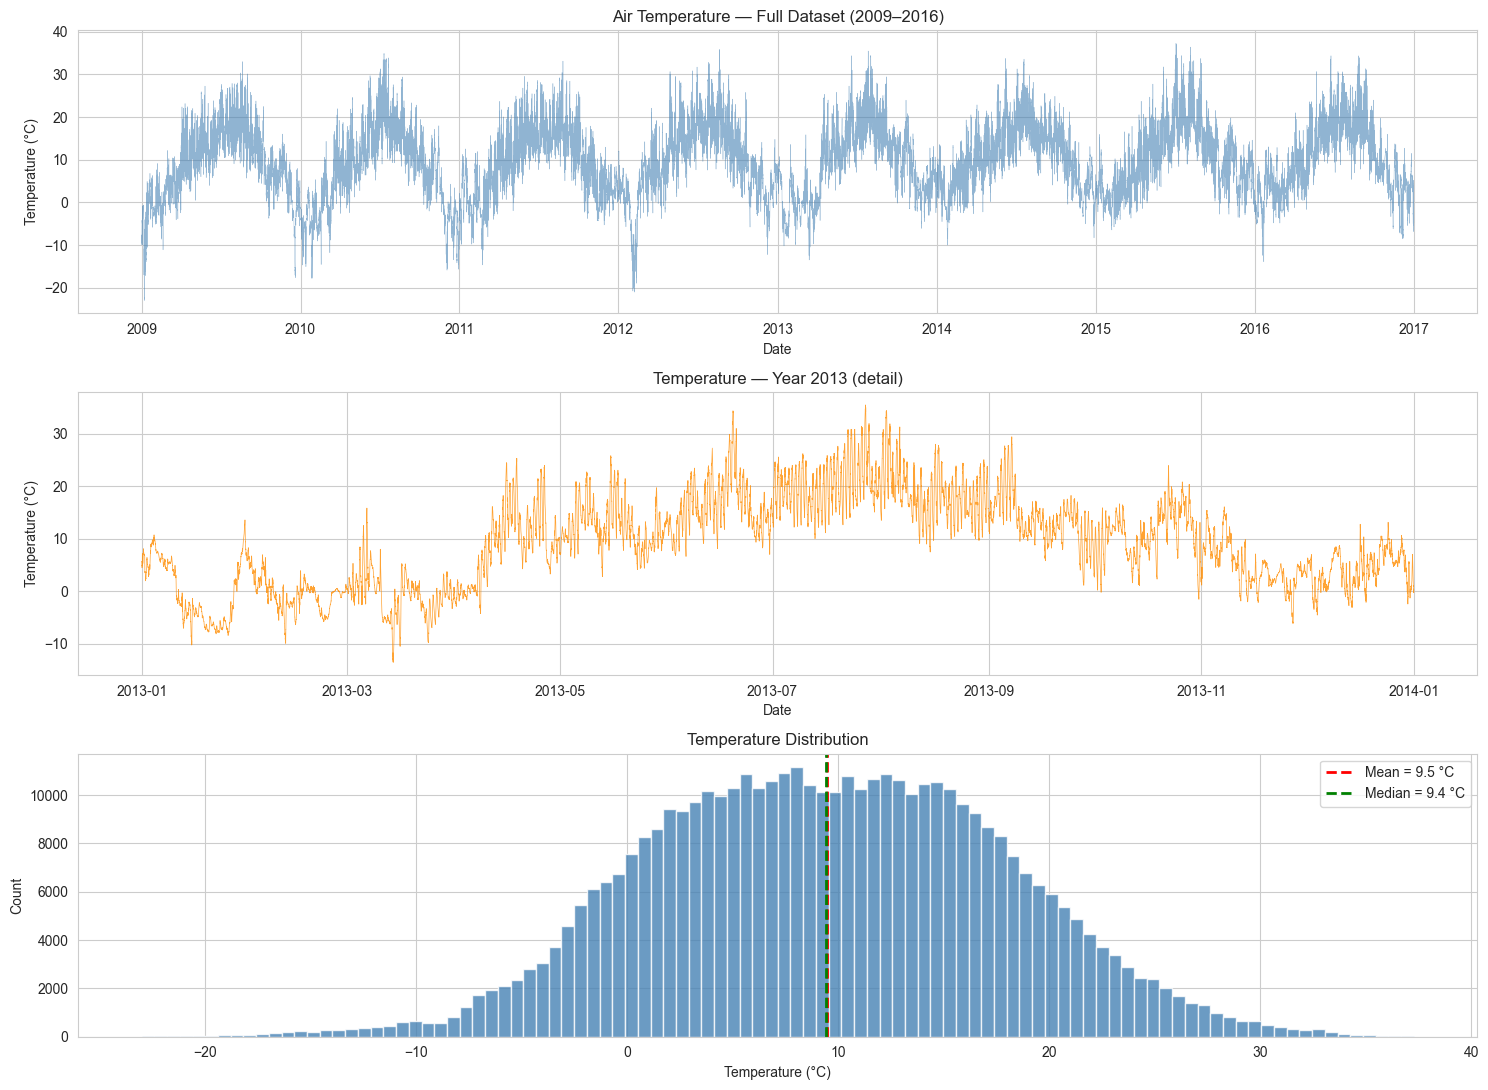

Temperature statistics:
count    420551.00
mean          9.45
std           8.42
min         -23.01
25%           3.36
50%           9.42
75%          15.47
max          37.28
Name: T (degC), dtype: float64


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# 1 — Full time series
axes[0].plot(df_raw.index, df_raw['T (degC)'],
             alpha=0.6, linewidth=0.3, color='steelblue')
axes[0].set_title('Air Temperature — Full Dataset (2009–2016)', fontsize=12)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_xlabel('Date')

# 2 — One representative year
mask_2013 = df_raw.index.year == 2013
axes[1].plot(df_raw.index[mask_2013], df_raw['T (degC)'][mask_2013],
             alpha=0.8, linewidth=0.5, color='darkorange')
axes[1].set_title('Temperature — Year 2013 (detail)', fontsize=12)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Date')

# 3 — Distribution
axes[2].hist(df_raw['T (degC)'], bins=100, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[2].axvline(df_raw['T (degC)'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {df_raw["T (degC)"].mean():.1f} °C')
axes[2].axvline(df_raw['T (degC)'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Median = {df_raw["T (degC)"].median():.1f} °C')
axes[2].set_title('Temperature Distribution', fontsize=12)
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Temperature statistics:')
print(df_raw['T (degC)'].describe().round(2))

- Existe um padrão sazonal muito evidente (temperaturas mais altas no verão e mais baixas no inverno).
- A temperatura média é aproximadamente 9,5 °C.
- A média e a mediana são muito semelhantes (9,5 °C e 9,4 °C), indicando uma distribuição relativamente equilibrada.
- Os valores observados variam aproximadamente entre -23 °C e 37 °C.

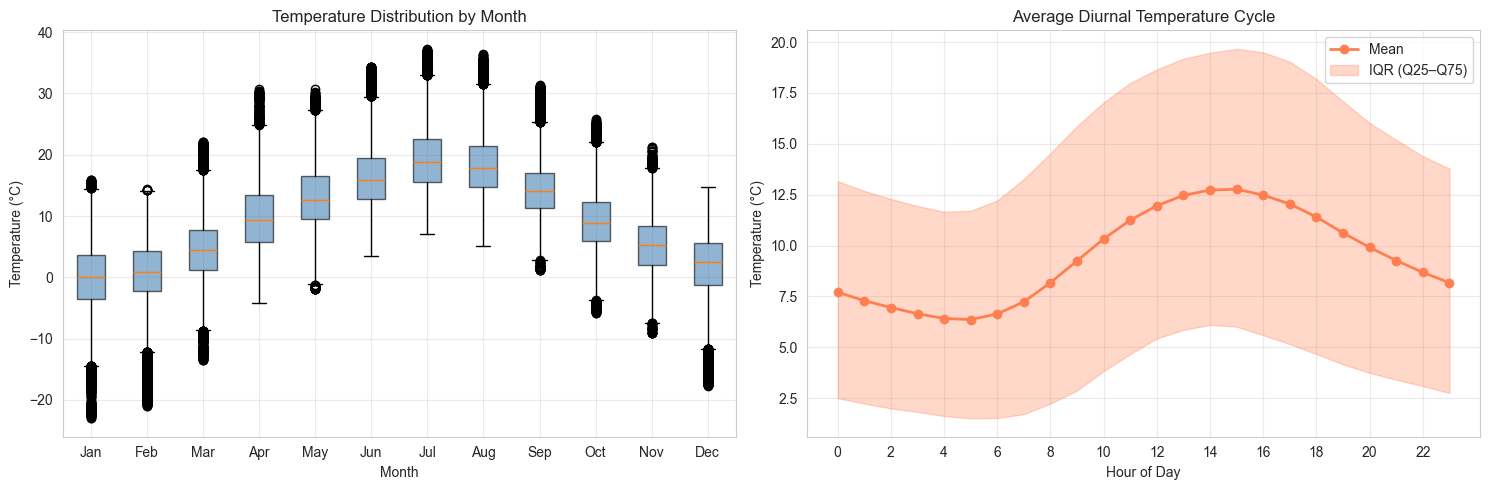

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Monthly boxplot
df_raw['month'] = df_raw.index.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_data = [df_raw['T (degC)'][df_raw['month'] == m].values for m in range(1, 13)]
axes[0].boxplot(monthly_data, labels=month_labels, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Temperature Distribution by Month', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.4)

# Hourly average (diurnal cycle)
df_raw['hour'] = df_raw.index.hour
hourly_mean = df_raw.groupby('hour')['T (degC)'].mean()
hourly_q25  = df_raw.groupby('hour')['T (degC)'].quantile(0.25)
hourly_q75  = df_raw.groupby('hour')['T (degC)'].quantile(0.75)

axes[1].plot(hourly_mean.index, hourly_mean.values,
             marker='o', color='coral', linewidth=2, label='Mean')
axes[1].fill_between(hourly_mean.index, hourly_q25, hourly_q75,
                     alpha=0.3, color='coral', label='IQR (Q25–Q75)')
axes[1].set_title('Average Diurnal Temperature Cycle', fontsize=12)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('eda_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

Foi analisada a sazonalidade da temperatura através de duas perspetivas. Primeiro, foi construído um boxplot mensal para comparar a distribuição das temperaturas ao longo dos diferentes meses do ano. Em seguida, foi calculado o ciclo diário médio da temperatura, agrupando os registos por hora do dia e representando a média e a variabilidade dos valores observados.

Pelos gráficos percebe-se que:

- Os meses de verão (junho, julho e agosto) apresentam temperaturas **mais elevadas**.
- Os meses de inverno (dezembro, janeiro e fevereiro) apresentam temperaturas **mais baixas**.
- Ao longo do dia, a temperatura tende a atingir valores **mínimos durante a madrugada** e **máximos durante a tarde**.

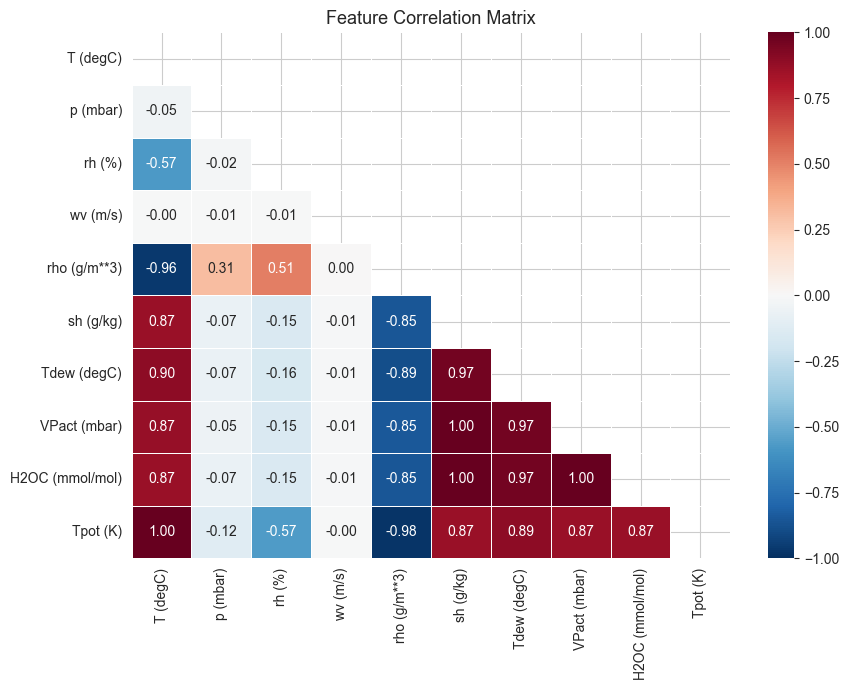

Top correlations with T (degC):
Tpot (K)           0.997
rho (g/m**3)       0.963
Tdew (degC)        0.896
VPact (mbar)       0.868
H2OC (mmol/mol)    0.867
sh (g/kg)          0.867
rh (%)             0.572
p (mbar)           0.045
wv (m/s)           0.005
Name: T (degC), dtype: float64


In [7]:
# Correlation heatmap — select numeric columns of interest
corr_cols = [
    'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rho (g/m**3)', 'sh (g/kg)', 'Tdew (degC)', 'VPact (mbar)', 'H2OC (mmol/mol)', 'Tpot (K)'
]
corr_df = df_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            annot_kws={'size': 10}, vmin=-1, vmax=1,
            linewidths=0.5)

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with T (degC):')
temp_corr = corr_df['T (degC)'].drop('T (degC)').abs().sort_values(ascending=False)
print(temp_corr.round(3))

Foi calculada a matriz de correlação entre a temperatura e outras variáveis meteorológicas selecionadas. 

Para isso, foram utilizados os coeficientes de correlação de Pearson e os resultados foram representados através de um heatmap. Posteriormente, foram identificadas e apresentadas as variáveis com maior correlação com a temperatura, permitindo compreender quais os atributos potencialmente mais relevantes para a previsão da variável alvo.

## 3. Preprocessing

### Steps
1. **Feature selection** — seleção de variáveis fisicamente relevantes para o problema, excluindo colunas derivadas redundantes, como **VPmax** e **VPdef**. Estas foram removidas devido à sua elevada redundância com outras variáveis de humidade e pressão de vapor, reduzindo a multicolinearidade do conjunto de dados

2. **Bad-value handling** — substituição dos valores inválidos `wv = -9999` (erro do sensor) por valores nulos (*NaN*) e preenchimento utilizando o valor válido anterior (*forward-fill*).

3. **Cyclical encoding** — a direção do vento (0°–360°) foi codificada através das componentes seno e cosseno `(sin, cos)` para preservar a sua natureza circular.

4. **Temporal features** — foram criadas variáveis temporais cíclicas para a hora do dia e para o dia do ano, permitindo capturar padrões diários e sazonais.

5. **Downsampling** — redução da frequência dos dados de registos a cada 10 minutos para registos horários através da agregação pela média (compressão aproximada de 6×).

6. **Normalisation** — **MinMaxScaler** ajustado apenas aos dados de treino e posteriormente aplicado aos conjuntos de validação e teste, garantindo que os valores ficam no intervalo `[0, 1]` e respeitam o requisito de não negatividade do RMSLE.

7. **Sequence construction** — construção de sequências através de uma janela deslizante de tamanho **W**, gerando entradas `X ∈ ℝ^(W × F)` e uma variável alvo `y = T[t + 24]`, correspondente à temperatura prevista para 24 horas no futuro.

8. **Chronological split** — divisão cronológica dos dados em **70% para treino**, **15% para validação** e **15% para teste**, sem embaralhamento dos registos, evitando assim *data leakage*.

In [8]:
# Feature selection & bad-value handling 
RAW_FEATURES = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rho (g/m**3)', 'sh (g/kg)', 'wd (deg)']
TARGET = 'T (degC)'

df = df_raw[RAW_FEATURES].copy()

# Sensor error: wv == -9999 means missing
df['wv (m/s)'] = df['wv (m/s)'].replace(-9999.0, np.nan)

# Forward-fill then backward-fill for any remaining NaN
df = df.ffill().bfill()

print(f'Missing values after cleaning: {df.isnull().sum().sum()}')
print(f'Shape: {df.shape}')
df.describe().round(2)

Missing values after cleaning: 0
Shape: (420551, 7)


,T (degC),p (mbar),rh (%),wv (m/s),rho (g/m**3),sh (g/kg),wd (deg)
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,9.45,989.21,76.01,2.13,1216.06,6.02,174.74
std,8.42,8.36,16.48,1.54,39.98,2.66,86.68
min,-23.01,913.60,12.95,0.00,1059.45,0.50,0.00
25%,3.36,984.20,65.21,0.99,1187.49,3.92,124.90
50%,9.42,989.58,79.30,1.76,1213.79,5.59,198.10
75%,15.47,994.72,89.40,2.86,1242.77,7.80,234.10
max,37.28,1015.35,100.00,28.49,1393.54,18.13,360.00


Com base na análise de correlação, foram removidas as variáveis **Tpot (K)**, **Tdew (degC)**, **VPmax (mbar)**, **VPact (mbar)**, **VPdef (mbar)** e **H2OC (mmol/mol)** por apresentarem elevada redundância relativamente a outras variáveis selecionadas. Em particular, **Tpot (K)** mostrou uma correlação praticamente perfeita com a temperatura, enquanto **VPact (mbar)**, **H2OC (mmol/mol)** e **Tdew (degC)** apresentaram correlações muito elevadas com as variáveis relacionadas com a humidade. 

A remoção destas variáveis permitiu reduzir a multicolinearidade do conjunto de dados, simplificar o modelo e evitar a utilização de informação repetida, mantendo apenas os atributos considerados mais relevantes e distintos para a previsão da temperatura.

In [9]:
# Cyclical encoding 
# Wind direction: 0°–360° is circular - encode as (sin, cos)
df['wd_sin'] = np.sin(2 * np.pi * df['wd (deg)'] / 360.0)
df['wd_cos'] = np.cos(2 * np.pi * df['wd (deg)'] / 360.0)
df = df.drop(columns=['wd (deg)'])

# Time-based cyclical features
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24.0)
df['doy_sin']  = np.sin(2 * np.pi * df.index.dayofyear / 365.0)
df['doy_cos']  = np.cos(2 * np.pi * df.index.dayofyear / 365.0)

# Hourly downsampling 
df_hourly = df.resample('h').mean().dropna()

print(f'Original  : {len(df):,}  records (10-min)')
print(f'Hourly    : {len(df_hourly):,}  records (1-hour)')
print(f'Features  : {df_hourly.columns.tolist()}')
print(f'N features: {df_hourly.shape[1]}')
df_hourly.head(3)

Original  : 420,551  records (10-min)
Hourly    : 70,041  records (1-hour)
Features  : ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rho (g/m**3)', 'sh (g/kg)', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
N features: 12


,T (degC),p (mbar),rh (%),wv (m/s),rho (g/m**3),sh (g/kg),wd_sin,wd_cos,hour_sin,hour_cos,doy_sin,doy_cos
Date Time,,,,,,,,,,,,
2009-01-01 00:00:00,-8.304000,996.528,93.780000,0.520000,1309.196000,1.910000,0.086357,-0.874474,0.000000,1.000000,0.017213,0.999852
2009-01-01 01:00:00,-8.065000,996.525,93.933333,0.316667,1307.981667,1.951667,0.100133,-0.901708,0.258819,0.965926,0.017213,0.999852
2009-01-01 02:00:00,-8.763333,996.745,93.533333,0.248333,1311.816667,1.836667,-0.185926,-0.759236,0.500000,0.866025,0.017213,0.999852


A direção do vento foi convertida para as componentes seno e cosseno de forma a preservar a sua natureza circular. 

Foram também criadas variáveis temporais cíclicas para representar a hora do dia e o dia do ano, permitindo capturar padrões diários e sazonais. 

Por fim, os dados foram agregados para frequência horária através da média dos registos de 10 minutos, reduzindo o volume de dados e o ruído presente nas medições.

In [10]:
# --- Chronological train / validation / test split ---------------------------
N = len(df_hourly)
TRAIN_END = int(N * 0.70)
VAL_END   = int(N * 0.85)

train_df = df_hourly.iloc[:TRAIN_END]
val_df   = df_hourly.iloc[TRAIN_END:VAL_END]
test_df  = df_hourly.iloc[VAL_END:]

print(f'Train : {len(train_df):>6,} hours  ({len(train_df)/N*100:.1f}%)')
print(f'  {train_df.index[0]}  →  {train_df.index[-1]}')
print(f'Val   : {len(val_df):>6,} hours  ({len(val_df)/N*100:.1f}%)')
print(f'  {val_df.index[0]}  →  {val_df.index[-1]}')
print(f'Test  : {len(test_df):>6,} hours  ({len(test_df)/N*100:.1f}%)')
print(f'  {test_df.index[0]}  →  {test_df.index[-1]}')

# --- MinMax normalisation: fit on train only ---------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df).astype(np.float32)
val_scaled   = scaler.transform(val_df).astype(np.float32)
test_scaled  = scaler.transform(test_df).astype(np.float32)

TARGET_IDX = list(df_hourly.columns).index(TARGET)
N_FEATURES = df_hourly.shape[1]
print(f'\nTarget "{TARGET}" at index {TARGET_IDX}')
print(f'Number of features : {N_FEATURES}')
print(f'Scaled train range : [{train_scaled.min():.3f}, {train_scaled.max():.3f}]')

Train : 49,028 hours  (70.0%)
  2009-01-01 00:00:00  →  2014-08-05 19:00:00
Val   : 10,506 hours  (15.0%)
  2014-08-05 20:00:00  →  2015-10-18 04:00:00
Test  : 10,507 hours  (15.0%)
  2015-10-18 05:00:00  →  2017-01-01 00:00:00

Target "T (degC)" at index 0
Number of features : 12
Scaled train range : [0.000, 1.000]


Os dados foram divididos cronologicamente em conjuntos de treino (70%), validação (15%) e teste (15%), preservando a ordem temporal das observações e evitando data leakage. 

De seguida, foi aplicada a normalização Min-Max, ajustada apenas aos dados de treino e posteriormente aplicada aos conjuntos de validação e teste. Por fim, foi identificada a posição da variável alvo (temperatura) para utilização na construção das sequências temporais.

In [11]:
def create_sequences(data, window_size, horizon=24):
    
    X, y = [], []
    total = len(data) - window_size - horizon + 1
    for i in range(total):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1, TARGET_IDX])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


HORIZON = 24  # predict temperature 24 hours ahead
print(f'Forecasting horizon : {HORIZON} hours')

Forecasting horizon : 24 hours


Foi criada uma função para gerar sequências temporais através de uma janela deslizante. 

Cada sequência utiliza um conjunto de observações passadas como entrada e associa-lhes a temperatura observada 24 horas no futuro como variável alvo. Este procedimento converte a série temporal num formato adequado para o treino dos modelos RNN e LSTM.

In [12]:
# Build datasets for multiple window sizes
WINDOW_SIZES = {
    '24h': 24,
    '48h': 48,
    '168h': 168
}
datasets = {}

for name, W in WINDOW_SIZES.items():
    X_tr, y_tr = create_sequences(train_scaled, W, HORIZON)
    X_va, y_va = create_sequences(val_scaled,   W, HORIZON)
    X_te, y_te = create_sequences(test_scaled,  W, HORIZON)

    datasets[name] = {
        'window': W,
        'X_train': X_tr, 'y_train': y_tr,
        'X_val':   X_va, 'y_val':   y_va,
        'X_test':  X_te, 'y_test':  y_te,
    }
    print(f'Window = {name} ({W} steps):')
    print(f'  Train  X{X_tr.shape}  y{y_tr.shape}')
    print(f'  Val    X{X_va.shape}   y{y_va.shape}')
    print(f'  Test   X{X_te.shape}   y{y_te.shape}')
    print()

Window = 24h (24 steps):
  Train  X(48981, 24, 12)  y(48981,)
  Val    X(10459, 24, 12)   y(10459,)
  Test   X(10460, 24, 12)   y(10460,)



Window = 48h (48 steps):
  Train  X(48957, 48, 12)  y(48957,)
  Val    X(10435, 48, 12)   y(10435,)
  Test   X(10436, 48, 12)   y(10436,)



Window = 168h (168 steps):
  Train  X(48837, 168, 12)  y(48837,)
  Val    X(10315, 168, 12)   y(10315,)
  Test   X(10316, 168, 12)   y(10316,)



## 4. Model Architectures

### Matriz de Experiências

| Config | Arquitetura        | Janela | Unidades | Sementes | Responde a |
| ------ | ------------------ | ------ | -------- | -------- | ---------- |
| 1      | SimpleRNN          | 24h    | 64       | 3        | RQ1, RQ3   |
| 2      | LSTM               | 24h    | 64       | 3        | RQ1, RQ3   |
| 3      | GRU                | 24h    | 64       | 3        | RQ1, RQ3   |
| 4      | BiLSTM             | 24h    | 64       | 1        | RQ3        |
| 5      | SimpleRNN          | 48h    | 64       | 1        | RQ2        |
| 6      | LSTM               | 48h    | 64       | 1        | RQ2        |
| 7      | SimpleRNN          | 168h   | 64       | 1        | RQ2        |
| 8      | LSTM               | 168h   | 64       | 1        | RQ2        |

### Justificações de Design

- **Ativação de saída — linear**: a previsão de temperatura é um problema de **regressão** com alvo contínuo. Uma saída linear **não satura** nos extremos, ao contrário da *sigmoid* (que comprime os valores para perto de 0 e 1 e penaliza precisamente as temperaturas mais baixas e mais altas — as caudas da distribuição). O RMSLE, que exige argumentos não-negativos, é assegurado aplicando `clip([0, 1])` às previsões escaladas apenas na fase de avaliação.

- **Loss — MSE**: penaliza mais fortemente desvios de grande magnitude e apresenta convergência estável com o otimizador Adam.

- **Optimiser — Adam** (*lr = 1 × 10⁻³*): taxa de aprendizagem adaptativa, robusto perante gradientes esparsos e favorecendo uma convergência eficiente.

- **Métrica de treino — MAE**: acompanhada nas curvas de treino por ser diretamente interpretável; o RMSLE oficial é calculado no fim (avaliação).

- **Dropout (0.2)**: regularização à saída da camada recorrente, ajudando a reduzir o sobreajuste (*overfitting*).

- **Dense(32, relu) bridge**: projeção não linear entre a representação recorrente e a saída escalar.

- **EarlyStopping (patience = 10)** e **ReduceLROnPlateau (patience = 5)**: interrompem o treino e reduzem a taxa de aprendizagem quando a perda de validação estagna, prevenindo o sobreajuste.

- **Treino com múltiplas sementes**: as três arquiteturas centrais a 24 h são treinadas com **3 sementes (42, 7, 123)** e reportadas como **média ± desvio-padrão**. Isto é essencial para distinguir diferenças *reais* entre arquiteturas do simples **ruído de inicialização** dos pesos. As configurações de janela maior (48h, 168h), computacionalmente mais dispendiosas, usam uma semente e são comparadas contra a banda de ruído assim estabelecida.

### Construção das Arquiteturas Recorrentes

Foi definida uma função genérica `build_model` para criar as diferentes arquiteturas (**SimpleRNN**, **LSTM**, **GRU** e **Bidirectional LSTM**), todas com o mesmo número de unidades recorrentes, uma camada de *dropout*, uma camada densa intermédia e uma **saída linear** (regressão). A compilação usa o otimizador **Adam**, função de perda **MSE** e a métrica **MAE**. A função `run_config` treina cada configuração ao longo de várias sementes e devolve as métricas agregadas (média e desvio-padrão), guardando ainda uma execução representativa para os gráficos. Em baixo apresenta-se o `model.summary()` do LSTM com janela de 24 h.

In [13]:
SEEDS = [42, 7, 123]

def set_seeds(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)


def build_model(arch, window_size, units=64, dropout=0.2, lr=1e-3):

    model = Sequential(name=f'{arch}_w{window_size}h_u{units}')
    input_shape = (window_size, N_FEATURES)

    rnn_layers = {'SimpleRNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}
    if arch in rnn_layers:
        model.add(rnn_layers[arch](units, input_shape=input_shape, return_sequences=False))
    elif arch == 'BiLSTM':
        model.add(layers.Bidirectional(
            layers.LSTM(units, return_sequences=False), input_shape=input_shape))
    else:
        raise ValueError(f'Unknown architecture: {arch}')

    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(32, activation='relu'))
    # Linear output: standard for regression; no saturation at temperature extremes.
    model.add(layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae'],
    )
    return model


# Preview architecture for LSTM w=24
build_model('LSTM', 24).summary()

Model: "LSTM_w24h_u64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def train_model(model, X_tr, y_tr, X_va, y_va, epochs=150, batch_size=256):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ]
    return model.fit(
        X_tr, y_tr, validation_data=(X_va, y_va),
        epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=0,
    )


def evaluate_model(model, X_te, y_te):
    y_pred_sc = model.predict(X_te, verbose=0).flatten()

    # Inverse-transform to degrees Celsius
    dummy_true = np.zeros((len(y_te), N_FEATURES), dtype=np.float32)
    dummy_pred = np.zeros((len(y_te), N_FEATURES), dtype=np.float32)
    dummy_true[:, TARGET_IDX] = y_te
    dummy_pred[:, TARGET_IDX] = y_pred_sc
    y_true_c = scaler.inverse_transform(dummy_true)[:, TARGET_IDX]
    y_pred_c = scaler.inverse_transform(dummy_pred)[:, TARGET_IDX]

    rmse_c = float(np.sqrt(mean_squared_error(y_true_c, y_pred_c)))
    mae_c  = float(mean_absolute_error(y_true_c, y_pred_c))

    # Official RMSLE on the scaled domain; clip to [0,1] so log1p is always defined.
    rmsle_val = float(rmsle(
        tf.constant(np.clip(y_te, 0.0, 1.0), dtype=tf.float32),
        tf.constant(np.clip(y_pred_sc, 0.0, 1.0), dtype=tf.float32)
    ).numpy())

    return {'rmsle_scaled': rmsle_val, 'rmse_c': rmse_c, 'mae_c': mae_c,
            'y_true': y_true_c, 'y_pred': y_pred_c,
            'y_true_sc': y_te, 'y_pred_sc': y_pred_sc, 'X_test': X_te}


def run_config(arch, window, units=64, seeds=SEEDS):
    """Train one configuration over several seeds; return aggregated metrics
    (mean and std) plus the first-seed run kept for plotting."""
    ds = datasets[window]
    per_seed, rep = [], None
    for s in seeds:
        set_seeds(s)
        mdl  = build_model(arch, ds['window'], units=units)
        hist = train_model(mdl, ds['X_train'], ds['y_train'], ds['X_val'], ds['y_val'])
        met  = evaluate_model(mdl, ds['X_test'], ds['y_test'])
        per_seed.append(met)
        if rep is None:
            rep = {'history': hist.history, 'metrics': met}

    rmse = np.array([m['rmse_c'] for m in per_seed])
    mae  = np.array([m['mae_c']  for m in per_seed])
    rmsl = np.array([m['rmsle_scaled'] for m in per_seed])

    agg = {
        'arch': arch, 'window': window, 'units': units, 'n_seeds': len(seeds),
        'rmse_c': float(rmse.mean()),  'rmse_std': float(rmse.std()),
        'mae_c':  float(mae.mean()),   'mae_std':  float(mae.std()),
        'rmsle_scaled': float(rmsl.mean()), 'rmsle_std': float(rmsl.std()),
        'rmse_all': rmse.tolist(),
        'y_true': rep['metrics']['y_true'], 'y_pred': rep['metrics']['y_pred'],
        'y_true_sc': rep['metrics']['y_true_sc'], 'y_pred_sc': rep['metrics']['y_pred_sc'],
        'X_test': rep['metrics']['X_test'], 'epochs': len(rep['history']['loss']),
    }
    return agg, rep['history']


print('Training / evaluation / multi-seed helpers defined.')

Training / evaluation / multi-seed helpers defined.


---
## 5. Experiments

Todas as configurações são treinadas sequencialmente. As três arquiteturas centrais a 24 h correm com **3 sementes** (média ± desvio-padrão); as janelas maiores correm com 1 semente. O *early stopping* evita o sobre-treino e cada execução imprime as métricas finais de teste.

In [15]:
EXPERIMENTS = [
    {'name': 'SimpleRNN_w24',  'arch': 'SimpleRNN', 'window': '24h',  'seeds': SEEDS},
    {'name': 'LSTM_w24',       'arch': 'LSTM',      'window': '24h',  'seeds': SEEDS},
    {'name': 'GRU_w24',        'arch': 'GRU',       'window': '24h',  'seeds': SEEDS},
    {'name': 'BiLSTM_w24',     'arch': 'BiLSTM',    'window': '24h',  'seeds': [42]},
    {'name': 'SimpleRNN_w48',  'arch': 'SimpleRNN', 'window': '48h',  'seeds': [42]},
    {'name': 'LSTM_w48',       'arch': 'LSTM',      'window': '48h',  'seeds': [42]},
    {'name': 'SimpleRNN_w168', 'arch': 'SimpleRNN', 'window': '168h', 'seeds': [42]},
    {'name': 'LSTM_w168',      'arch': 'LSTM',      'window': '168h', 'seeds': [42]},
]

results, histories = {}, {}

for exp in EXPERIMENTS:
    print(f'\n{"="*60}')
    print(f'Training : {exp["name"]}  ({len(exp["seeds"])} seed(s))')
    print(f'{"="*60}')

    agg, hist = run_config(exp['arch'], exp['window'], seeds=exp['seeds'])
    results[exp['name']]   = {**agg, 'name': exp['name']}
    histories[exp['name']] = hist

    print(f'  RMSE (°C)      : {agg["rmse_c"]:.3f} +/- {agg["rmse_std"]:.3f}')
    print(f'  MAE  (°C)      : {agg["mae_c"]:.3f} +/- {agg["mae_std"]:.3f}')
    print(f'  RMSLE (scaled) : {agg["rmsle_scaled"]:.4f} +/- {agg["rmsle_std"]:.4f}')
    print(f'  Epochs (rep.)  : {agg["epochs"]}')

print('\nAll experiments complete.')


Training : SimpleRNN_w24  (3 seed(s))


  RMSE (°C)      : 2.849 +/- 0.039
  MAE  (°C)      : 2.242 +/- 0.031
  RMSLE (scaled) : 0.0321 +/- 0.0004
  Epochs (rep.)  : 53

Training : LSTM_w24  (3 seed(s))


  RMSE (°C)      : 2.919 +/- 0.132
  MAE  (°C)      : 2.307 +/- 0.112
  RMSLE (scaled) : 0.0328 +/- 0.0013
  Epochs (rep.)  : 42

Training : GRU_w24  (3 seed(s))


  RMSE (°C)      : 2.837 +/- 0.045
  MAE  (°C)      : 2.243 +/- 0.041
  RMSLE (scaled) : 0.0319 +/- 0.0004
  Epochs (rep.)  : 36

Training : BiLSTM_w24  (1 seed(s))


  RMSE (°C)      : 2.801 +/- 0.000
  MAE  (°C)      : 2.203 +/- 0.000
  RMSLE (scaled) : 0.0317 +/- 0.0000
  Epochs (rep.)  : 46

Training : SimpleRNN_w48  (1 seed(s))


  RMSE (°C)      : 2.812 +/- 0.000
  MAE  (°C)      : 2.216 +/- 0.000
  RMSLE (scaled) : 0.0317 +/- 0.0000
  Epochs (rep.)  : 54

Training : LSTM_w48  (1 seed(s))


  RMSE (°C)      : 2.821 +/- 0.000
  MAE  (°C)      : 2.215 +/- 0.000
  RMSLE (scaled) : 0.0318 +/- 0.0000
  Epochs (rep.)  : 42

Training : SimpleRNN_w168  (1 seed(s))


  RMSE (°C)      : 2.841 +/- 0.000
  MAE  (°C)      : 2.235 +/- 0.000
  RMSLE (scaled) : 0.0320 +/- 0.0000
  Epochs (rep.)  : 39

Training : LSTM_w168  (1 seed(s))


  RMSE (°C)      : 2.851 +/- 0.000
  MAE  (°C)      : 2.251 +/- 0.000
  RMSLE (scaled) : 0.0320 +/- 0.0000
  Epochs (rep.)  : 28

All experiments complete.


In [16]:
# Hyperparameter exploration: number of recurrent units for the leading
# architecture (GRU @ 24h). Single seed (42) for a fast, controlled sweep.
print('=== Hyperparameter search: GRU @ 24h, units in {32, 64, 128} ===\n')

hp_rows = []
for u in [32, 64, 128]:
    set_seeds(42)
    mdl  = build_model('GRU', 24, units=u)
    hist = train_model(mdl, datasets['24h']['X_train'], datasets['24h']['y_train'],
                       datasets['24h']['X_val'],   datasets['24h']['y_val'])
    met  = evaluate_model(mdl, datasets['24h']['X_test'], datasets['24h']['y_test'])
    hp_rows.append({'Units': u, 'Params': mdl.count_params(),
                    'RMSE (°C)': round(met['rmse_c'], 3),
                    'MAE (°C)':  round(met['mae_c'], 3),
                    'Epochs': len(hist.history['loss'])})
    print(f'  units={u:>3}  params={mdl.count_params():>6}  '
          f'RMSE={met["rmse_c"]:.3f} C  MAE={met["mae_c"]:.3f} C')

hp_df = pd.DataFrame(hp_rows)
hp_df

=== Hyperparameter search: GRU @ 24h, units in {32, 64, 128} ===



  units= 32  params=  5505  RMSE=3.065 C  MAE=2.428 C


  units= 64  params= 17089  RMSE=2.792 C  MAE=2.198 C


  units=128  params= 58689  RMSE=2.782 C  MAE=2.194 C


,Units,Params,RMSE (°C),MAE (°C),Epochs
0,32,5505,3.065,2.428,29
1,64,17089,2.792,2.198,43
2,128,58689,2.782,2.194,39


### Otimização de hiperparâmetros — número de unidades recorrentes

Para documentar o processo de otimização de hiperparâmetros exigido pelo enunciado, fez-se uma pequena pesquisa sobre o número de unidades da camada recorrente (32, 64 e 128) na arquitetura líder (GRU, janela de 24 h), mantendo tudo o resto constante e fixando a semente. A tabela acima permite verificar se aumentar a capacidade do modelo se traduz, ou não, em ganho de desempenho — e a que custo de parâmetros. Como se observa, o ganho é marginal (dentro da própria banda de ruído entre sementes), pelo que **64 unidades** representam um bom compromisso entre capacidade e parcimónia, justificando a escolha usada em todas as restantes experiências.

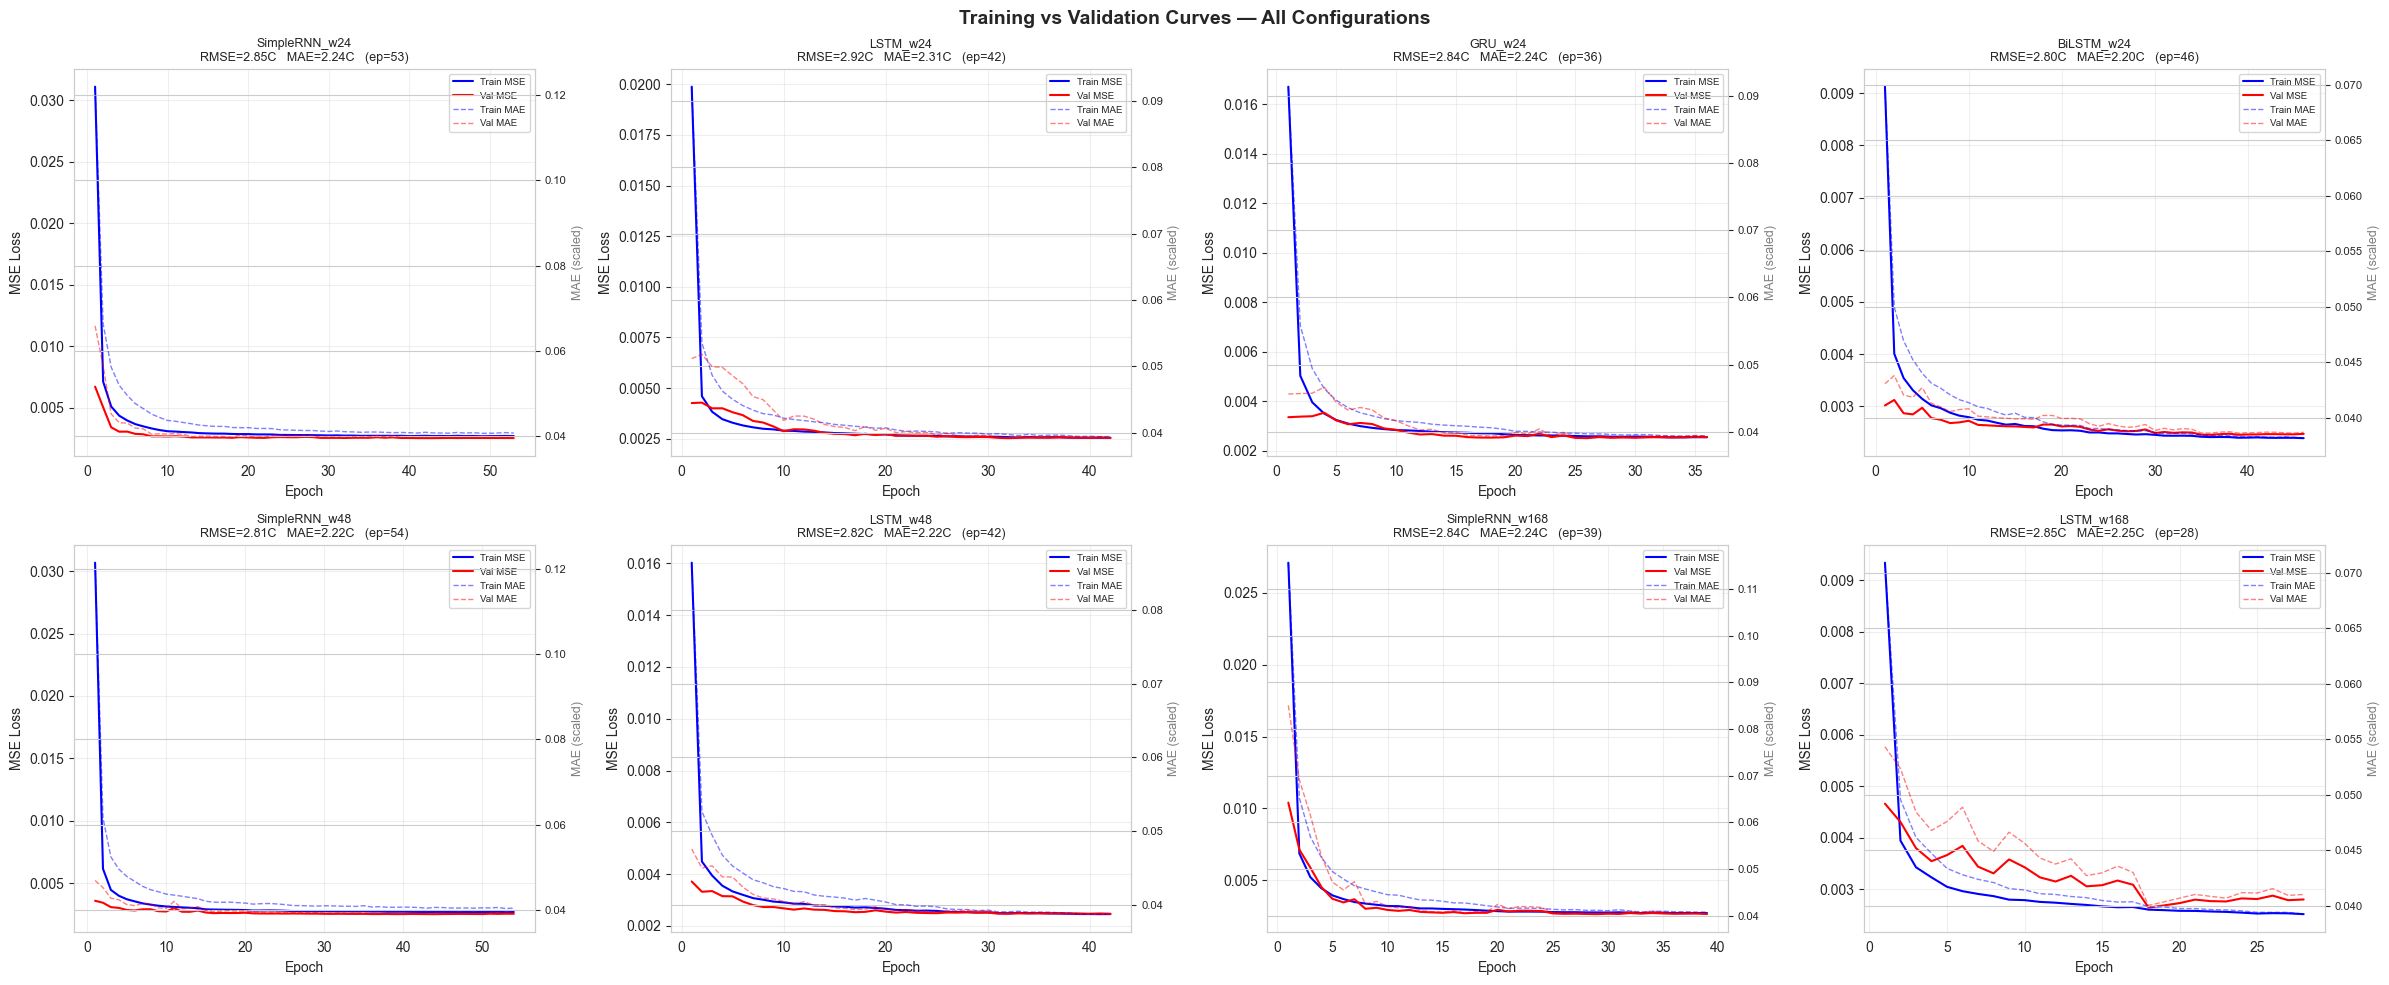

In [17]:
# Training curves — 2x4 grid (8 models). Representative seed per configuration.

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes_flat = axes.flatten()

for i, (exp_name, h) in enumerate(histories.items()):
    ax = axes_flat[i]
    eps = range(1, len(h['loss']) + 1)

    # MSE loss
    ax.plot(eps, h['loss'], 'b-', lw=1.5, label='Train MSE')
    ax.plot(eps, h['val_loss'], 'r-', lw=1.5, label='Val MSE')

    # MAE on secondary axis
    ax2 = ax.twinx()
    ax2.plot(eps, h['mae'], 'b--', lw=1.0, alpha=0.5, label='Train MAE')
    ax2.plot(eps, h['val_mae'], 'r--', lw=1.0, alpha=0.5, label='Val MAE')
    ax2.set_ylabel('MAE (scaled)', color='grey', fontsize=9)
    ax2.tick_params(axis='y', labelsize=8)

    stopped = len(h['loss'])
    info = results[exp_name]
    ax.set_title(
        f'{exp_name}\n'
        f'RMSE={info["rmse_c"]:.2f}C   MAE={info["mae_c"]:.2f}C   (ep={stopped})',
        fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

for j in range(len(histories), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Training vs Validation Curves — All Configurations',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Results Analysis

### Baselines ingénuos (referência)

Antes de comparar arquiteturas, é necessário estabelecer **baselines de referência**: sem eles, um RMSE de ~2.8 °C não é interpretável — não sabemos se os modelos aprenderam algo útil ou se apenas reproduzem a estrutura óbvia da série. São avaliados dois baselines, calculados diretamente sobre os dados (sem qualquer modelo treinado):

1. **Persistência** — `T̂(t+24h) = T(t)`: a previsão é a última temperatura observada na janela de entrada. Como o ciclo diário tem período de 24 h, este baseline é particularmente forte para este horizonte.
2. **Climatologia** — a previsão é a temperatura média do conjunto de **treino** para o par (mês, hora) do instante alvo, capturando os ciclos sazonal e diário médios.

Um modelo só demonstra valor (*skill*) se superar claramente estes baselines.

In [18]:
# Naive baselines — computed directly from the data (no model), in °C
W_BASE = 24           # align targets with the 24h-window test split
T_test = test_df[TARGET].values

idx = np.arange(W_BASE + HORIZON - 1, len(T_test))
y_true_base = T_test[idx]

# 1) Persistence: prediction = temperature 24h before the target
#    (= last observed value of the input window)
y_persist = T_test[idx - HORIZON]

# 2) Climatology: train-set mean temperature for the target's (month, hour)
clim = train_df.groupby([train_df.index.month, train_df.index.hour])[TARGET].mean()
target_times = test_df.index[idx]
y_clim = clim.loc[list(zip(target_times.month, target_times.hour))].values

# RMSLE on the scaled domain (same convention as the models)
t_min = scaler.data_min_[TARGET_IDX]
t_max = scaler.data_max_[TARGET_IDX]

def scale_T(y):
    return np.clip((y - t_min) / (t_max - t_min), 0.0, 1.0).astype(np.float32)

baseline_rows = []
for bname, y_hat in [('Persistence T(t)', y_persist), ('Climatology (month,hour)', y_clim)]:
    rmse_b  = float(np.sqrt(mean_squared_error(y_true_base, y_hat)))
    mae_b   = float(mean_absolute_error(y_true_base, y_hat))
    rmsle_b = float(rmsle(tf.constant(scale_T(y_true_base)),
                          tf.constant(scale_T(y_hat))).numpy())
    baseline_rows.append({
        'Configuration': bname, 'Architecture': 'Baseline', 'Window': '—',
        'RMSLE (scaled)': round(rmsle_b, 4), 'RMSE (°C)': round(rmse_b, 3),
        'MAE (°C)': round(mae_b, 3), 'Epochs': '—',
    })
    print(f'{bname:26s} RMSE = {rmse_b:.3f} °C   MAE = {mae_b:.3f} °C   '
          f'RMSLE(scaled) = {rmsle_b:.4f}')

baseline_df = pd.DataFrame(baseline_rows)

Persistence T(t)           RMSE = 3.235 °C   MAE = 2.489 °C   RMSLE(scaled) = 0.0364
Climatology (month,hour)   RMSE = 4.544 °C   MAE = 3.588 °C   RMSLE(scaled) = 0.0510


In [19]:
# Summary comparison table — headline metric: RMSE (°C), with seed std
rows = []
for name, r in results.items():
    rows.append({
        'Configuration':  name,
        'Architecture':   r['arch'],
        'Window':         r['window'],
        'RMSE (°C)':      round(r['rmse_c'], 3),
        'RMSE +/-':       round(r['rmse_std'], 3),
        'MAE (°C)':       round(r['mae_c'], 3),
        'RMSLE (scaled)': round(r['rmsle_scaled'], 4),
        'Seeds':          r['n_seeds'],
        'Epochs':         r['epochs'],
    })

results_df = pd.DataFrame(rows).sort_values('RMSE (°C)').reset_index(drop=True)
full_df = pd.concat([results_df, baseline_df], ignore_index=True).sort_values('RMSE (°C)')

print('\n=== EXPERIMENT RESULTS (sorted by RMSE °C — headline metric) ===')
print('(RMSLE scaled is reported for completeness — see the methodological note in Section 0.)')
print(full_df.to_string(index=False))
full_df


=== EXPERIMENT RESULTS (sorted by RMSE °C — headline metric) ===
(RMSLE scaled is reported for completeness — see the methodological note in Section 0.)
           Configuration Architecture Window  RMSE (°C)  RMSE +/-  MAE (°C)  RMSLE (scaled)  Seeds Epochs
              BiLSTM_w24       BiLSTM    24h      2.801     0.000     2.203          0.0317    1.0     46
           SimpleRNN_w48    SimpleRNN    48h      2.812     0.000     2.216          0.0317    1.0     54
                LSTM_w48         LSTM    48h      2.821     0.000     2.215          0.0318    1.0     42
                 GRU_w24          GRU    24h      2.837     0.045     2.243          0.0319    3.0     36
          SimpleRNN_w168    SimpleRNN   168h      2.841     0.000     2.235          0.0320    1.0     39
           SimpleRNN_w24    SimpleRNN    24h      2.849     0.039     2.242          0.0321    3.0     53
               LSTM_w168         LSTM   168h      2.851     0.000     2.251          0.0320    1.0     2

,Configuration,Architecture,Window,RMSE (°C),RMSE +/-,MAE (°C),RMSLE (scaled),Seeds,Epochs
0,BiLSTM_w24,BiLSTM,24h,2.801,0.000,2.203,0.0317,1.0,46
1,SimpleRNN_w48,SimpleRNN,48h,2.812,0.000,2.216,0.0317,1.0,54
2,LSTM_w48,LSTM,48h,2.821,0.000,2.215,0.0318,1.0,42
3,GRU_w24,GRU,24h,2.837,0.045,2.243,0.0319,3.0,36
4,SimpleRNN_w168,SimpleRNN,168h,2.841,0.000,2.235,0.0320,1.0,39
5,SimpleRNN_w24,SimpleRNN,24h,2.849,0.039,2.242,0.0321,3.0,53
6,LSTM_w168,LSTM,168h,2.851,0.000,2.251,0.0320,1.0,28
7,LSTM_w24,LSTM,24h,2.919,0.132,2.307,0.0328,3.0,42
8,Persistence T(t),Baseline,—,3.235,NaN,2.489,0.0364,NaN,—
9,"Climatology (month,hour)",Baseline,—,4.544,NaN,3.588,0.0510,NaN,—


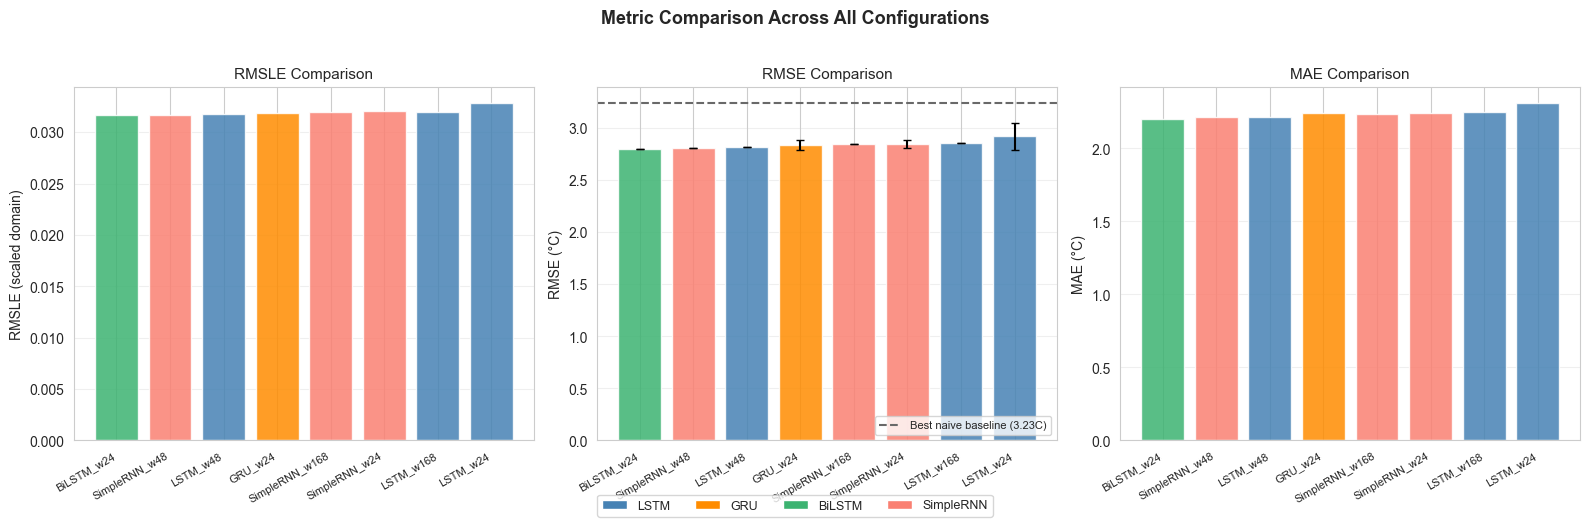

In [20]:
# Bar chart comparison (RMSE panel shows seed std as error bars)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names   = results_df['Configuration'].tolist()
rmsle_v = results_df['RMSLE (scaled)'].tolist()
rmse_v  = results_df['RMSE (°C)'].tolist()
mae_v   = results_df['MAE (°C)'].tolist()
rmse_e  = results_df['RMSE +/-'].tolist()

def color_for(n):
    if 'Bi' in n:   return 'mediumseagreen'
    if 'GRU' in n:  return 'darkorange'
    if 'LSTM' in n: return 'steelblue'
    return 'salmon'
colors = [color_for(n) for n in names]

panels = [
    (axes[0], rmsle_v, None,   'RMSLE (scaled domain)', 'RMSLE Comparison'),
    (axes[1], rmse_v,  rmse_e, 'RMSE (°C)',             'RMSE Comparison'),
    (axes[2], mae_v,   None,   'MAE (°C)',              'MAE Comparison'),
]
for ax, vals, errs, ylabel, title in panels:
    ax.bar(range(len(names)), vals, yerr=errs, capsize=3,
           color=colors, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

persist_rmse = float(baseline_df['RMSE (°C)'].min())
axes[1].axhline(persist_rmse, color='dimgrey', ls='--', lw=1.5,
                label=f'Best naive baseline ({persist_rmse:.2f}C)')
axes[1].legend(fontsize=8, loc='lower right')

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='steelblue',      label='LSTM'),
    Patch(facecolor='darkorange',     label='GRU'),
    Patch(facecolor='mediumseagreen', label='BiLSTM'),
    Patch(facecolor='salmon',         label='SimpleRNN'),
]
fig.legend(handles=legend_items, loc='lower center', ncol=4, fontsize=9, frameon=True)
plt.suptitle('Metric Comparison Across All Configurations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Best model (lowest RMSE °C — headline metric): summary and architecture
best_name = results_df.iloc[0]['Configuration']
best = results[best_name]
print(f'=== BEST MODEL: {best_name} ===')
print(f'Architecture : {best["arch"]}')
print(f'Window size  : {best["window"]}')
print(f'RMSE (°C)      : {best["rmse_c"]:.3f}')
print(f'MAE  (°C)      : {best["mae_c"]:.3f}')
print(f'RMSLE (scaled) : {best["rmsle_scaled"]:.4f}')
print()

# Rebuild and show summary of best model
best_model = build_model(best['arch'], datasets[best['window']]['window'])
best_model.summary()

# Optional: plot model graph (requires pydot + graphviz installed)
try:
    from tensorflow.keras.utils import plot_model
    plot_model(best_model, to_file='best_model_architecture.png',
               show_shapes=True, show_layer_names=True, dpi=120)
    print('Architecture diagram saved to best_model_architecture.png')
except Exception as e:
    print(f'(Architecture diagram skipped: {e})')

=== BEST MODEL: BiLSTM_w24 ===
Architecture : BiLSTM
Window size  : 24h
RMSE (°C)      : 2.801
MAE  (°C)      : 2.203
RMSLE (scaled) : 0.0317



Model: "BiLSTM_w24h_u64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,585 (170.25 KB)

 Trainable params: 43,585 (170.25 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Architecture diagram saved to best_model_architecture.png


---
## 7. Best Case / Worst Case Analysis

For the best-performing model (lowest **RMSE in °C** — the headline metric), we identify the **3 predictions with the smallest absolute error** (best cases) and the **3 with the largest absolute error** (worst cases). Each panel shows the historical temperature window used as input and marks the predicted vs. actual value 24 h ahead.

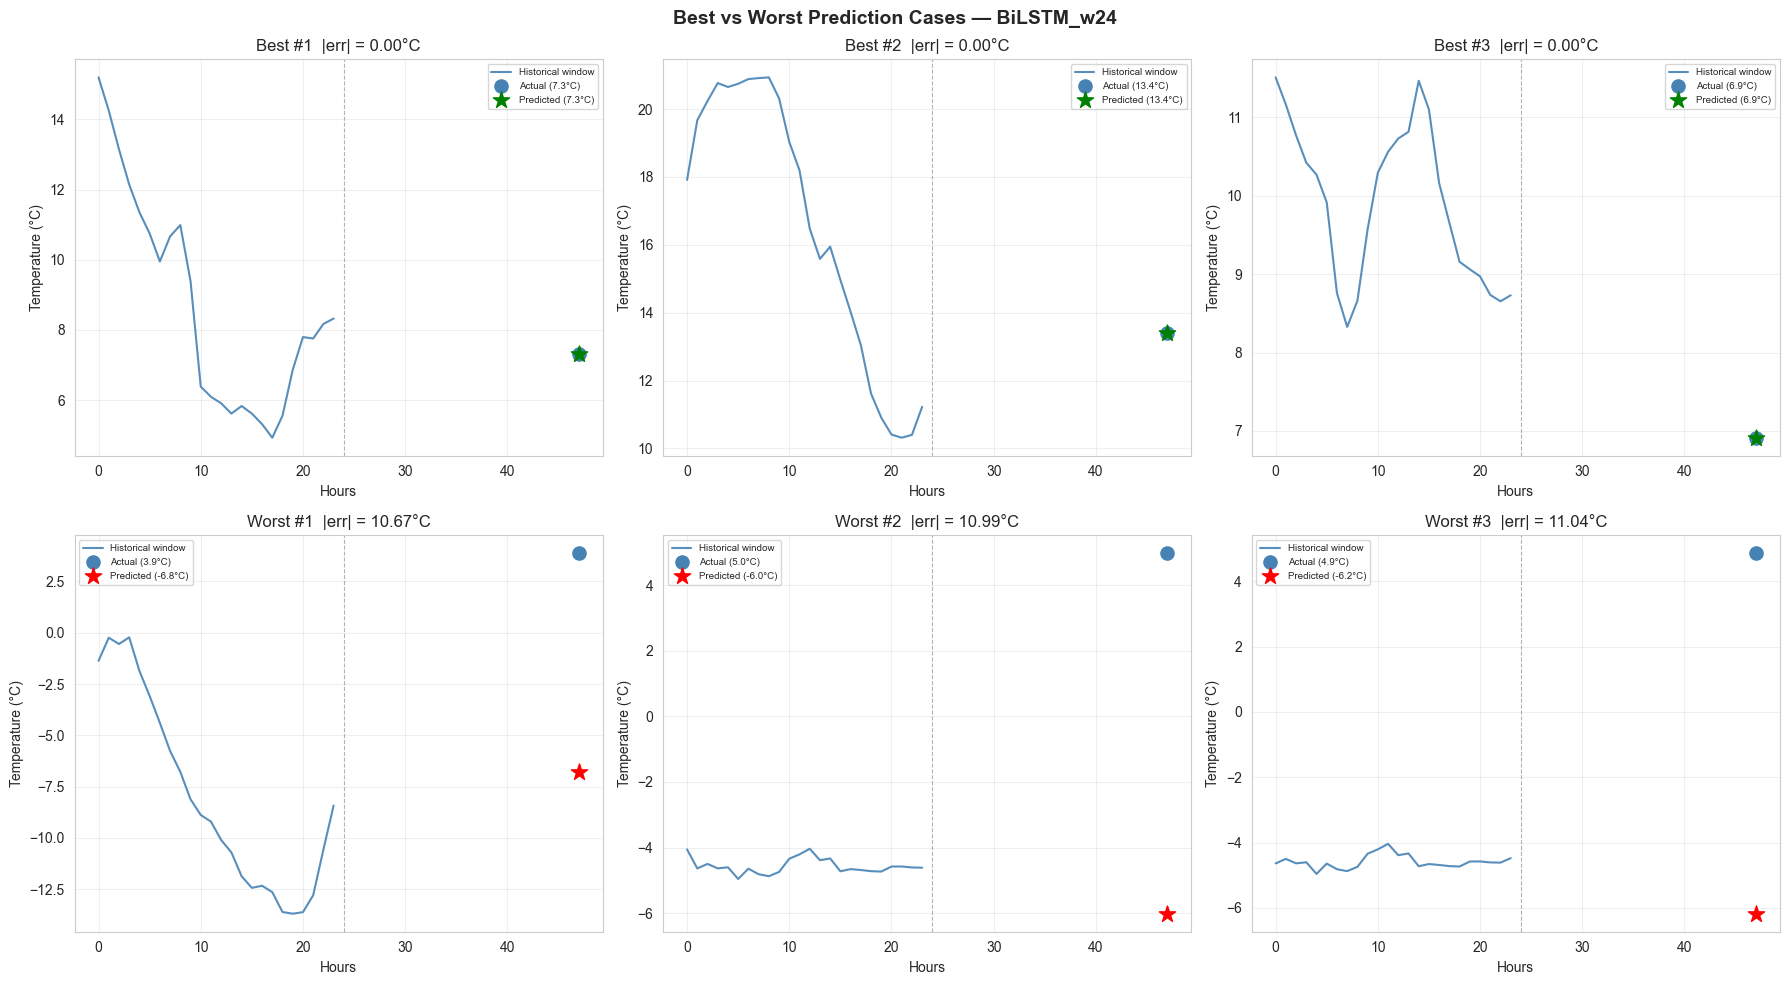

Best 3  errors (°C): [0. 0. 0.]
Worst 3 errors (°C): [10.67 10.99 11.04]


In [22]:
best_name = results_df.iloc[0]['Configuration']
best = results[best_name]
ds_best = datasets[best['window']]
W = ds_best['window']

errors = np.abs(best['y_true'] - best['y_pred'])
sorted_idx = np.argsort(errors)
best_idx  = sorted_idx[:3]
worst_idx = sorted_idx[-3:]


def plot_prediction_case(ax, idx, color, label):
    # Historical temperature window (in original °C)
    X_win_sc = ds_best['X_test'][idx, :, TARGET_IDX]  # scaled
    dummy    = np.zeros((len(X_win_sc), N_FEATURES), dtype=np.float32)
    dummy[:, TARGET_IDX] = X_win_sc
    T_hist = scaler.inverse_transform(dummy)[:, TARGET_IDX]

    t_axis = np.arange(len(T_hist))
    ax.plot(t_axis, T_hist, color='steelblue', lw=1.5, alpha=0.9,
            label='Historical window')

    # Target point (actual vs predicted)
    t_future = len(T_hist) + HORIZON - 1
    ax.scatter([t_future], [best['y_true'][idx]], color='steelblue',
               s=90, zorder=6, label=f'Actual ({best["y_true"][idx]:.1f}°C)')
    ax.scatter([t_future], [best['y_pred'][idx]], color=color,
               marker='*', s=150, zorder=7,
               label=f'Predicted ({best["y_pred"][idx]:.1f}°C)')

    ax.axvline(len(T_hist), color='grey', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=7)
    ax.set_title(f'{label}  |err| = {errors[idx]:.2f}°C')
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, idx in enumerate(best_idx):
    plot_prediction_case(axes[0, col], idx, 'green', f'Best #{col+1}')

for col, idx in enumerate(worst_idx):
    plot_prediction_case(axes[1, col], idx, 'red', f'Worst #{col+1}')

plt.suptitle(f'Best vs Worst Prediction Cases — {best_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('best_worst_cases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best 3  errors (°C): {errors[best_idx].round(2)}')
print(f'Worst 3 errors (°C): {errors[worst_idx].round(2)}')

---
## 8. Predictions vs Actual — Time Series View

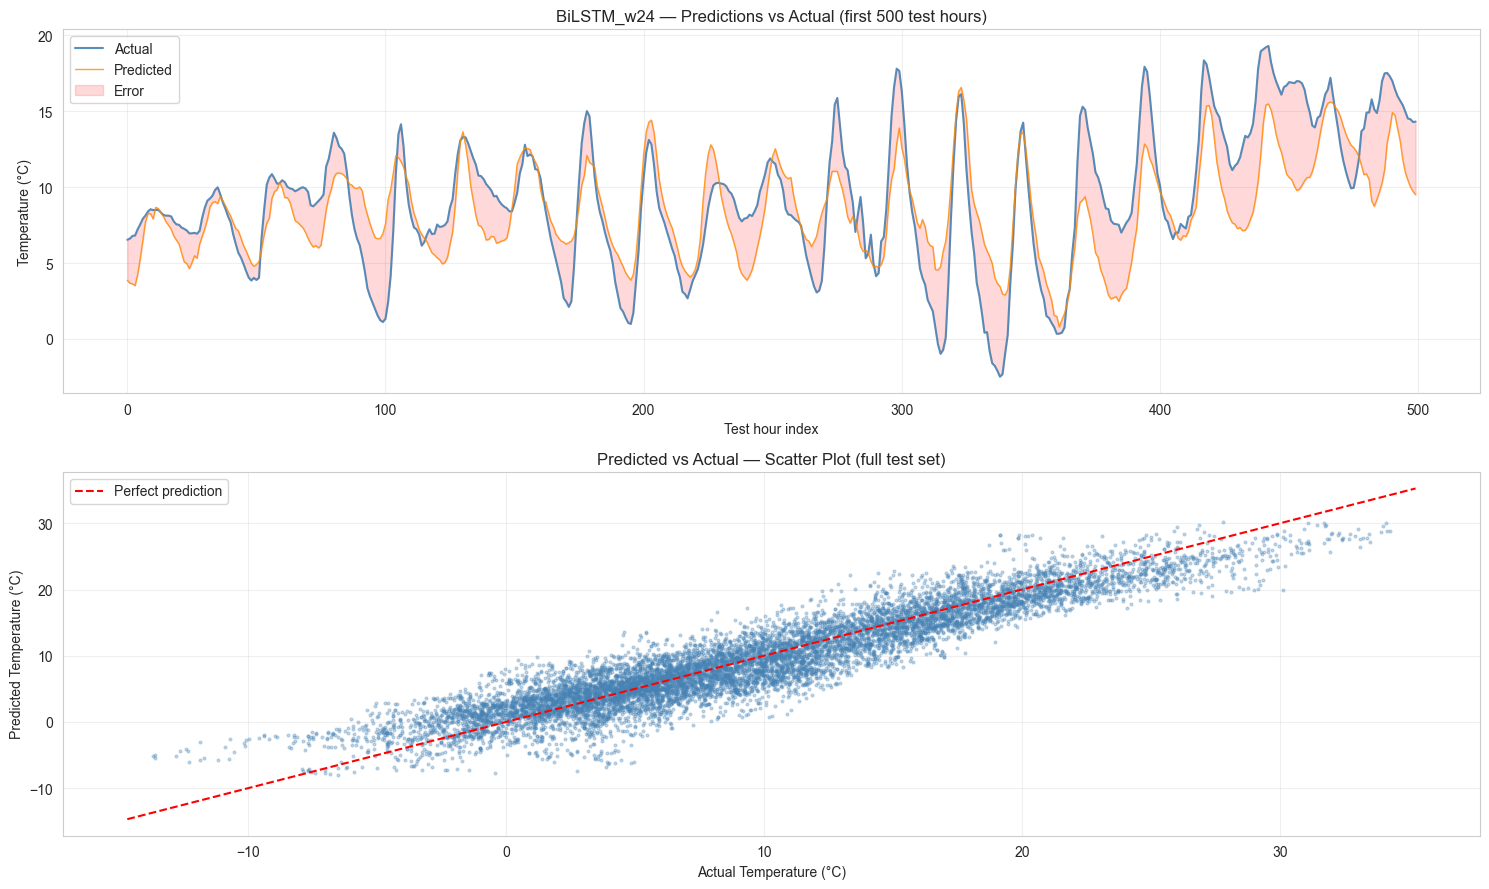

Pearson r (predictions vs actual): 0.9334


In [23]:
# Plot a 500-point slice of test set predictions vs actual
N_PLOT = 500

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

# Full 500-step window
axes[0].plot(best['y_true'][:N_PLOT], color='steelblue', lw=1.5,
             alpha=0.9, label='Actual')
axes[0].plot(best['y_pred'][:N_PLOT], color='darkorange', lw=1.0,
             alpha=0.8, label='Predicted')
axes[0].fill_between(range(N_PLOT),
                     best['y_true'][:N_PLOT],
                     best['y_pred'][:N_PLOT],
                     alpha=0.15, color='red', label='Error')
axes[0].set_title(f'{best_name} — Predictions vs Actual (first {N_PLOT} test hours)',
                  fontsize=12)
axes[0].set_xlabel('Test hour index')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Scatter: predicted vs actual
axes[1].scatter(best['y_true'], best['y_pred'],
                alpha=0.3, s=4, color='steelblue', rasterized=True)
lim_min = min(best['y_true'].min(), best['y_pred'].min()) - 1
lim_max = max(best['y_true'].max(), best['y_pred'].max()) + 1
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title('Predicted vs Actual — Scatter Plot (full test set)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation coefficient
cc = np.corrcoef(best['y_true'], best['y_pred'])[0, 1]
print(f'Pearson r (predictions vs actual): {cc:.4f}')

---
## 9. Discussion of Research Questions

### RQ1 — SimpleRNN vs LSTM vs GRU

Comparam-se as três arquiteturas recorrentes na mesma janela (24 h) e com as mesmas *features*, usando a média ± desvio-padrão sobre as 3 sementes. A questão-chave é: a diferença entre arquiteturas é **maior do que o ruído de inicialização**?

In [24]:
print('=== RQ1: SimpleRNN vs LSTM vs GRU  (window = 24h, mean +/- std over seeds) ===')
for a in ['SimpleRNN_w24', 'LSTM_w24', 'GRU_w24']:
    r = results[a]
    print(f'  {r["arch"]:10s} RMSE = {r["rmse_c"]:.3f} +/- {r["rmse_std"]:.3f} C   '
          f'MAE = {r["mae_c"]:.3f} +/- {r["mae_std"]:.3f} C   (seeds={r["n_seeds"]})')

# Is the gap between architectures larger than the seed-to-seed noise?
sr, ls = results['SimpleRNN_w24'], results['LSTM_w24']
gap   = abs(sr['rmse_c'] - ls['rmse_c'])
noise = sr['rmse_std'] + ls['rmse_std']
print(f'\nLSTM vs SimpleRNN gap = {gap:.3f} C   |   combined seed noise ~ {noise:.3f} C')
print('=> A diferenca', 'NAO E' if gap < noise else 'E', 'distinguivel do ruido de inicializacao.')

=== RQ1: SimpleRNN vs LSTM vs GRU  (window = 24h, mean +/- std over seeds) ===
  SimpleRNN  RMSE = 2.849 +/- 0.039 C   MAE = 2.242 +/- 0.031 C   (seeds=3)
  LSTM       RMSE = 2.919 +/- 0.132 C   MAE = 2.307 +/- 0.112 C   (seeds=3)
  GRU        RMSE = 2.837 +/- 0.045 C   MAE = 2.243 +/- 0.041 C   (seeds=3)

LSTM vs SimpleRNN gap = 0.070 C   |   combined seed noise ~ 0.172 C
=> A diferenca NAO E distinguivel do ruido de inicializacao.


In [25]:
print('=== RQ2: Window size impact (RMSE °C) ===')
for arch in ['SimpleRNN', 'LSTM']:
    line = f'{arch:10s}'
    for w in ['24', '48', '168']:
        r = results[f'{arch}_w{w}']
        line += f'  | {w}h: {r["rmse_c"]:.3f}'
    print(line)

print(f'\nReferencia de ruido entre sementes a 24h ~ '
      f'{results["LSTM_w24"]["rmse_std"]:.3f} C (LSTM). '
      'Diferencas menores que este valor nao sao significativas.')

=== RQ2: Window size impact (RMSE °C) ===
SimpleRNN   | 24h: 2.849  | 48h: 2.812  | 168h: 2.841
LSTM        | 24h: 2.919  | 48h: 2.821  | 168h: 2.851

Referencia de ruido entre sementes a 24h ~ 0.132 C (LSTM). Diferencas menores que este valor nao sao significativas.


=== RQ3: All configurations ranked by RMSE (°C) ===
 Configuration Architecture Window  RMSE (°C)  RMSE +/-  MAE (°C)  RMSLE (scaled)
    BiLSTM_w24       BiLSTM    24h      2.801     0.000     2.203          0.0317
 SimpleRNN_w48    SimpleRNN    48h      2.812     0.000     2.216          0.0317
      LSTM_w48         LSTM    48h      2.821     0.000     2.215          0.0318
       GRU_w24          GRU    24h      2.837     0.045     2.243          0.0319
SimpleRNN_w168    SimpleRNN   168h      2.841     0.000     2.235          0.0320
 SimpleRNN_w24    SimpleRNN    24h      2.849     0.039     2.242          0.0321
     LSTM_w168         LSTM   168h      2.851     0.000     2.251          0.0320
      LSTM_w24         LSTM    24h      2.919     0.132     2.307          0.0328

=== Robustez de BiLSTM_w24: RMSE / MAE por estacao ===
  Inverno    n= 2929  RMSE=3.352 C  MAE=2.656 C
  Primavera  n= 2208  RMSE=2.505 C  MAE=1.937 C
  Verao      n= 2208  RMSE=2.607 C  MAE=2.080 C
  Outono  

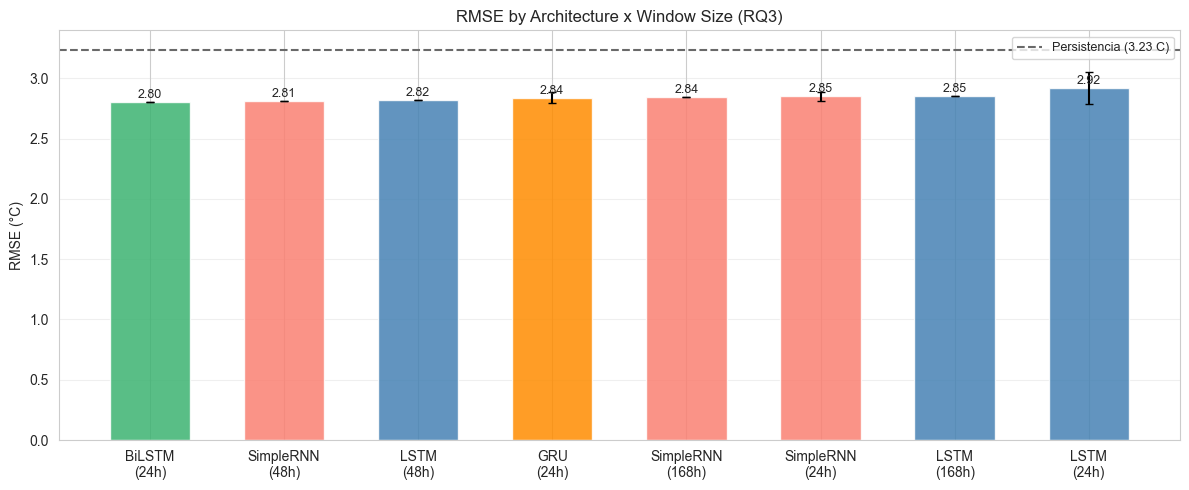

In [26]:
print('=== RQ3: All configurations ranked by RMSE (°C) ===')
print(results_df[['Configuration', 'Architecture', 'Window',
                  'RMSE (°C)', 'RMSE +/-', 'MAE (°C)', 'RMSLE (scaled)']].to_string(index=False))

# --- Robustness of the best model: error by season ----------------------------
best_name = results_df.iloc[0]['Configuration']
best = results[best_name]
Wb = datasets[best['window']]['window']

target_idx    = np.arange(Wb + HORIZON - 1, len(test_df))
target_months = test_df.index[target_idx].month
season_of = {12:'Inverno', 1:'Inverno', 2:'Inverno', 3:'Primavera', 4:'Primavera',
             5:'Primavera', 6:'Verao', 7:'Verao', 8:'Verao',
             9:'Outono', 10:'Outono', 11:'Outono'}
seasons = np.array([season_of[m] for m in target_months])
abs_err = np.abs(best['y_true'] - best['y_pred'])

print(f'\n=== Robustez de {best_name}: RMSE / MAE por estacao ===')
for s in ['Inverno', 'Primavera', 'Verao', 'Outono']:
    mask = seasons == s
    if mask.sum():
        rmse_s = np.sqrt(np.mean((best['y_true'][mask] - best['y_pred'][mask])**2))
        print(f'  {s:10s} n={mask.sum():5d}  RMSE={rmse_s:.3f} C  MAE={abs_err[mask].mean():.3f} C')

# --- Grouped bar chart (architecture x window) on RMSE ------------------------
fig, ax = plt.subplots(figsize=(12, 5))
rq3 = results_df.copy()
rq3['Label'] = rq3['Architecture'] + '\n(' + rq3['Window'] + ')'
cmap = {'SimpleRNN':'salmon', 'LSTM':'steelblue', 'GRU':'darkorange', 'BiLSTM':'mediumseagreen'}
bars = ax.bar(rq3['Label'], rq3['RMSE (°C)'], yerr=rq3['RMSE +/-'], capsize=3,
              color=[cmap[a] for a in rq3['Architecture']],
              edgecolor='white', alpha=0.85, width=0.6)
for bar, val in zip(bars, rq3['RMSE (°C)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
persist_rmse = float(baseline_df['RMSE (°C)'].min())
ax.axhline(persist_rmse, color='dimgrey', ls='--', lw=1.5,
           label=f'Persistencia ({persist_rmse:.2f} C)')
ax.set_ylabel('RMSE (°C)')
ax.set_title('RMSE by Architecture x Window Size (RQ3)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rq3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Modelos vs. Baselines — os modelos têm *skill*?

A comparação com os baselines ingénuos contextualiza todos os resultados anteriores:

| Referência | RMSE (°C) | MAE (°C) |
|---|---|---|
| Climatologia (média (mês, hora) do treino) | 4.544 | 3.588 |
| Persistência (T̂(t+24h) = T(t)) | 3.235 | 2.489 |
| Melhor modelo RNN (BiLSTM, 24h) | 2.801 | 2.203 |
| Pior modelo RNN (LSTM, 24h) | 2.919 | 2.307 |

**Interpretação:**

- **Todos** os modelos superam a persistência (RMSE entre 2.80 e 2.92 °C vs. 3.235 °C, uma melhoria de **~10 a 13%**) e, com larga folga, a climatologia. As redes recorrentes aprendem, portanto, estrutura real para além de «amanhã ≈ hoje» — têm *skill* genuíno, embora a margem sobre a persistência seja modesta.
- Essa margem modesta explica a **quase indistinção entre todas as configurações**: as 8 experiências (SimpleRNN, LSTM, GRU, BiLSTM × janelas de 24/48/168 h) cabem todas num intervalo de apenas ~0.12 °C, que é **do mesmo tamanho do desvio-padrão entre sementes** de um único modelo (±0.132 °C no LSTM a 24 h). Por outras palavras, a escolha de arquitetura e de janela influencia o resultado **menos do que a simples aleatoriedade da inicialização dos pesos**. A previsão a 24 h é dominada pelos ciclos diário e sazonal, já fornecidos ao modelo através das *features* cíclicas (`hour`, `doy`) e da própria temperatura atual; o ganho possível sobre a persistência é limitado e qualquer arquitetura recorrente o captura de forma semelhante.
- Note-se ainda que **todos os modelos e ambos os baselines satisfazem RMSLE (scaled) < 1** (valores ≈ 0.03–0.05), confirmando a nota metodológica da Secção 0: o requisito do enunciado não discrimina modelos neste problema, ao contrário do RMSE em °C.

---

### Key Findings (conclusões alinhadas com os resultados)

> As conclusões seguintes derivam diretamente das tabelas e gráficos acima, e não de expectativas teóricas. A comparação correta é sempre feita contra a **banda de ruído entre sementes** (±0.13 °C de RMSE), abaixo da qual as diferenças não são significativas.

- **RQ1 — Tipo de célula (SimpleRNN vs. LSTM vs. GRU, 24 h):** as três arquiteturas são **estatisticamente indistinguíveis**. Em média sobre 3 sementes: SimpleRNN = 2.849 ± 0.039 °C, GRU = 2.837 ± 0.045 °C, LSTM = 2.919 ± 0.132 °C. A diferença entre LSTM e SimpleRNN (0.070 °C) é **inferior ao ruído de inicialização combinado** (~0.172 °C); o LSTM teve mesmo a pior média e a maior variância. O mecanismo de portas (*gating*) do LSTM **não traz vantagem** aqui, porque a previsão a 24 h não depende de dependências temporais de longo prazo que a SimpleRNN não consiga captar — a informação relevante está nas últimas observações e nas *features* cíclicas.

- **RQ2 — Tamanho da janela (24h / 48h / 168h):** o tamanho da janela tem **efeito desprezável**. Para a SimpleRNN: 24h = 2.849, 48h = 2.812, 168h = 2.841 °C; para o LSTM: 24h = 2.919, 48h = 2.821, 168h = 2.851 °C. A janela de 48 h é marginalmente a melhor, mas a diferença para as restantes está **dentro da banda de ruído** (±0.13 °C). Em particular, alargar o contexto para 168 h (uma semana) **não melhora** o desempenho — pelo contrário, tende a piorá-lo ligeiramente e a aumentar o custo de treino —, porque uma janela de 24 h já contém um ciclo diário completo, que é a estrutura dominante para este horizonte.

- **RQ3 — Combinação arquitetura × janela, qualidade e robustez:** todas as 8 configurações se situam entre **2.80 e 2.92 °C** de RMSE e **todas superam a persistência** (3.235 °C) em ~10–13%, com correlação de Pearson ≈ 0.93 entre previsto e real. Como o intervalo entre configurações (~0.12 °C) é comparável ao ruído entre sementes, **nenhuma combinação é significativamente superior**: o «melhor» modelo (BiLSTM a 24 h, 2.801 °C, uma só semente) está dentro da incerteza dos demais. Quanto à **robustez**, o erro do melhor modelo é maior no **inverno** (RMSE = 3.35 °C) e menor na **primavera** (2.51 °C); o inverno concentra os eventos frios extremos e maior variabilidade sinóptica, mais difíceis de prever, sendo também onde se concentram os piores casos individuais (erros até ~11 °C).

**Conclusão global:** para a previsão de temperatura a 24 h em Jena, a qualidade do modelo é determinada muito mais pela **formulação do problema** (horizonte, *features* cíclicas, normalização) do que pela escolha entre RNN, LSTM, GRU ou BiLSTM ou pelo tamanho da janela. A contribuição mais valiosa do trabalho não é «encontrar a melhor arquitetura», mas **demonstrar, com múltiplas sementes e baselines, que as arquiteturas são equivalentes neste regime** e que todas batem a persistência por uma margem modesta mas real.